In [1]:
# notebook debugging preamble
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def wave(freq, phase, t):
    return np.cos(2 * np.pi * freq * t + phase)

In [35]:
f0 = 1
fs = 3
duration = 10
t = np.linspace(0, duration, duration * 1000, endpoint=False)
n = np.linspace(0, duration, duration * fs, endpoint=False)
y_n = wave(f0, 0, n)
y_t = wave(f0, 0, t)

In [36]:
len(n)

30

In [37]:
n

array([0.        , 0.33333333, 0.66666667, 1.        , 1.33333333,
       1.66666667, 2.        , 2.33333333, 2.66666667, 3.        ,
       3.33333333, 3.66666667, 4.        , 4.33333333, 4.66666667,
       5.        , 5.33333333, 5.66666667, 6.        , 6.33333333,
       6.66666667, 7.        , 7.33333333, 7.66666667, 8.        ,
       8.33333333, 8.66666667, 9.        , 9.33333333, 9.66666667])

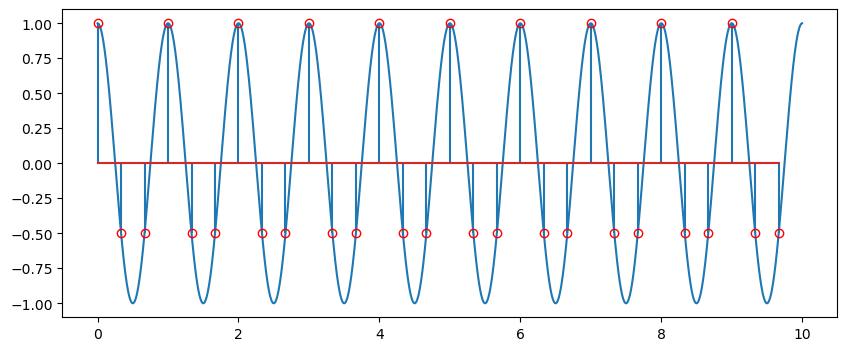

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(t, y_t)
marker, _, _ = plt.stem(n, y_n, markerfmt="ro")
marker.set_markerfacecolor("none")
# plt.plot()

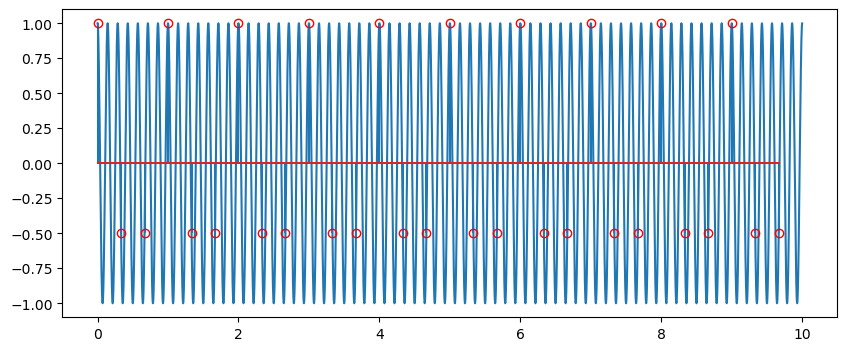

In [40]:
# infinite signals that passes through the sampling points
k = 2
y_prime = wave(f0 + k * fs, 0, t)
plt.figure(figsize=(10, 4))
plt.plot(t, y_prime, label=f"f = {f0 + k * fs} Hz")
marker, _, _ = plt.stem(n, y_n, markerfmt="ro")
marker.set_markerfacecolor("none")

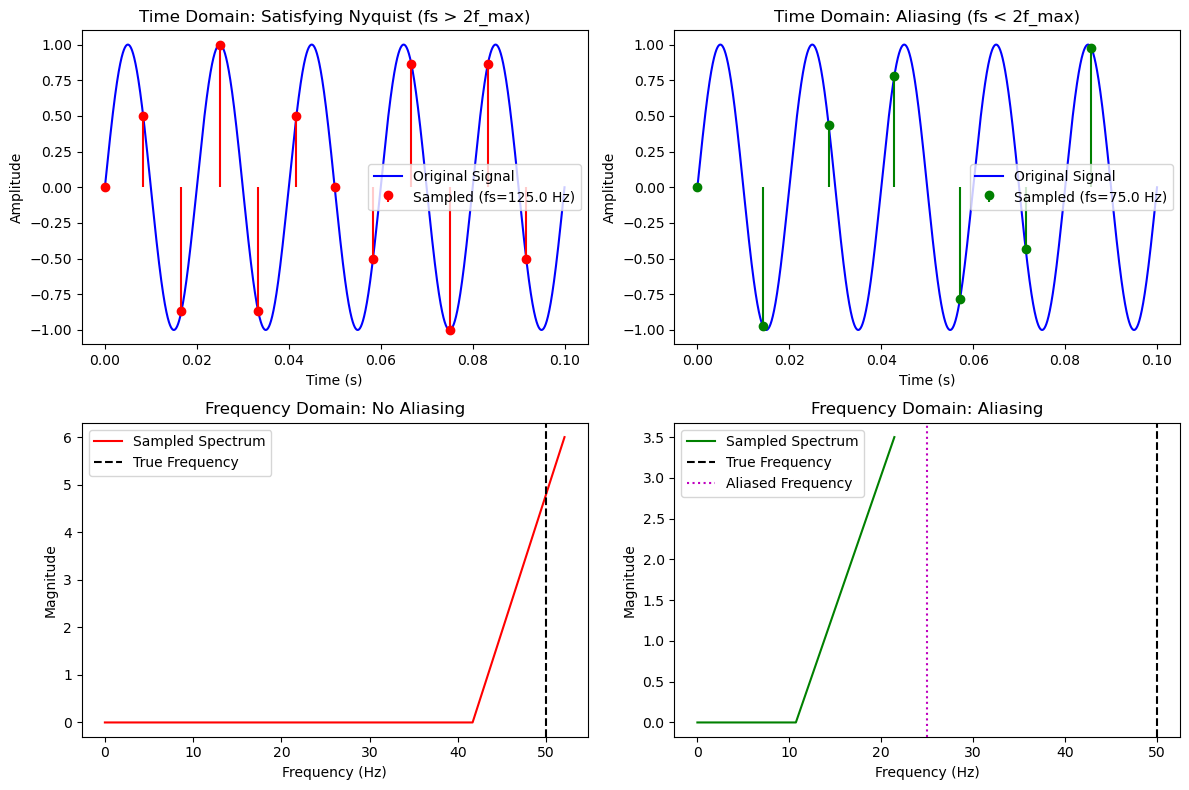

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# 参数设置
f_signal = 50  # 信号频率 (Hz)
f_s_nyquist = 2 * f_signal  # 奈奎斯特采样频率 (Hz)
duration = 0.1  # 信号持续时间 (秒)
t_continuous = np.linspace(0, duration, 10000)  # 高密度时间点（模拟连续信号）

# 生成连续信号
continuous_signal = np.sin(2 * np.pi * f_signal * t_continuous)

# 情况1：满足采样定理（fs > 2f_max）
f_s_high = 2.5 * f_signal  # 高于奈奎斯特频率
n_samples_high = int(duration * f_s_high)
t_samples_high = np.linspace(0, duration, n_samples_high, endpoint=False)
sampled_signal_high = np.sin(2 * np.pi * f_signal * t_samples_high)

# 情况2：不满足采样定理（fs < 2f_max），导致混叠
f_s_low = 1.5 * f_signal  # 低于奈奎斯特频率
n_samples_low = int(duration * f_s_low)
t_samples_low = np.linspace(0, duration, n_samples_low, endpoint=False)
sampled_signal_low = np.sin(2 * np.pi * f_signal * t_samples_low)


# 计算频谱
def compute_spectrum(signal, fs):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1 / fs)
    return xf[: n // 2], np.abs(yf[: n // 2])  # 取正频率部分


xf_high, yf_high = compute_spectrum(sampled_signal_high, f_s_high)
xf_low, yf_low = compute_spectrum(sampled_signal_low, f_s_low)

# 绘图
plt.figure(figsize=(12, 8))

# 时域信号对比
plt.subplot(2, 2, 1)
plt.plot(t_continuous, continuous_signal, "b-", label="Original Signal")
plt.stem(
    t_samples_high,
    sampled_signal_high,
    "r",
    markerfmt="ro",
    basefmt=" ",
    linefmt="r-",
    label=f"Sampled (fs={f_s_high} Hz)",
)
plt.title("Time Domain: Satisfying Nyquist (fs > 2f_max)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(t_continuous, continuous_signal, "b-", label="Original Signal")
plt.stem(
    t_samples_low,
    sampled_signal_low,
    "g",
    markerfmt="go",
    basefmt=" ",
    linefmt="g-",
    label=f"Sampled (fs={f_s_low} Hz)",
)
plt.title("Time Domain: Aliasing (fs < 2f_max)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# 频域频谱对比
plt.subplot(2, 2, 3)
plt.plot(xf_high, yf_high, "r-", label="Sampled Spectrum")
plt.axvline(x=f_signal, color="k", linestyle="--", label="True Frequency")
plt.title("Frequency Domain: No Aliasing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(xf_low, yf_low, "g-", label="Sampled Spectrum")
plt.axvline(x=f_signal, color="k", linestyle="--", label="True Frequency")
plt.axvline(x=f_s_low - f_signal, color="m", linestyle=":", label="Aliased Frequency")
plt.title("Frequency Domain: Aliasing")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()

plt.tight_layout()
plt.show()